In [13]:
# Cargar modelo mínimo y predecir sobre N muestras del HDF5 (KISS)
import numpy as np
import h5py
import tensorflow as tf

# Cargar el modelo (se espera que 'checkpoints/best_model.h5' exista)
model = tf.keras.models.load_model('checkpoints/best_model.h5')
model.summary()

# Leer N imágenes del HDF5
N = 8
X = []
with h5py.File('fractal_dataset.h5', 'r') as f:
    # sort groups by numeric k value (e.g. k_2, k_4, k_8, ...).
    groups = sorted([g for g in f.keys() if g.startswith('k_')], key=lambda s: int(s.split('_')[1]))
    for g in groups:
        ds = f[f"{g}/images"]
        for i in range(min(N - len(X), ds.shape[0])):
            im = np.array(ds[i], dtype=np.float32)
            if im.ndim == 2:
                im = im[..., np.newaxis]
            X.append(im)
        if len(X) >= N:
            break

X = np.stack(X, axis=0)
print('Loaded samples shape:', X.shape)

# Predecir y mostrar etiquetas predichas (top1)
preds = model.predict(X, batch_size=2)
pred_idx = preds.argmax(axis=1)
print('Predicted class indices (top1):', pred_idx.tolist())

# Mostrar top-3 probabilidades de la primera muestra
print('Top-3 probs for sample 0:', preds[0].argsort()[-3:][::-1], preds[0].max())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 512, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 512, 512, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,188,524 (4.53 MB)

 Trainable params: 1,188,518 (4.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (36.00 B)

Loaded samples shape: (8, 512, 512, 1)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step 
Predicted class indices (top1): [0, 0, 0, 0, 0, 0, 0, 0]
Top-3 probs for sample 0: [0 1 5] 0.99918324
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step 
Predicted class indices (top1): [0, 0, 0, 0, 0, 0, 0, 0]
Top-3 probs for sample 0: [0 1 5] 0.99918324


In [14]:
# Compute centroid prediction per image (KISS)
# For each image in `fractal_dataset_intermediate.h5` compute the predicted numeric k
# as the weighted average of trained k-values using the model's class probabilities.

import h5py
import numpy as np
import pandas as pd

inter_path = 'fractal_dataset_intermediate.h5'
bs = 8

# load model if missing
try:
    model
except NameError:
    import tensorflow as tf
    model = tf.keras.models.load_model('checkpoints/best_model.h5')

# map trained class index -> trained k value (reads training HDF5)
with h5py.File('fractal_dataset.h5', 'r') as f:
    # ensure numeric ordering of trained groups so class index <-> k-value mapping
    trained_groups = sorted([g for g in f.keys() if g.startswith('k_')], key=lambda s: int(s.split('_')[1]))
trained_k = np.array([int(g.split('_')[1]) for g in trained_groups], dtype=float)

rows = []
with h5py.File(inter_path, 'r') as f:
    groups = sorted([g for g in f.keys() if g.startswith('k_')], key=lambda s: int(s.split('_')[1]))
    for g in groups:
        ds = f[f'{g}/images']
        n = ds.shape[0]
        for i in range(0, n, bs):
            batch = ds[i:i+bs]
            if batch.ndim == 3:
                batch = batch[..., np.newaxis]
            probs = model.predict(batch, batch_size=bs)
            # centroid per image
            cents = probs.dot(trained_k)
            top1 = probs.argmax(axis=1)
            top1_prob = probs.max(axis=1)
            for j in range(len(cents)):
                rows.append({
                    'group': g,
                    'image_idx': i + j,
                    'true_k': int(g.split('_')[1]),
                    'centroid_k': float(cents[j]),
                    'top1_class_idx': int(top1[j]),
                    'top1_k': int(trained_k[int(top1[j])]),
                    'top1_prob': float(top1_prob[j])
                })
        print(f'Processed {g}: {n} images')

df = pd.DataFrame(rows)
# save results
out_csv = 'per_image_centroids.csv'
df.to_csv(out_csv, index=False)

# Print quick summaries per group
print('Per-group centroid summary (mean +/- std):')
print(df.groupby('group')['centroid_k'].agg(['mean','std','count']).round(3))

print(f'Per-image centroids saved to {out_csv}')

# Optionally show a small sample
print('\nFirst 10 rows:')
print(df.head(10))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━

Prepared X shape: (120, 512, 512, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step


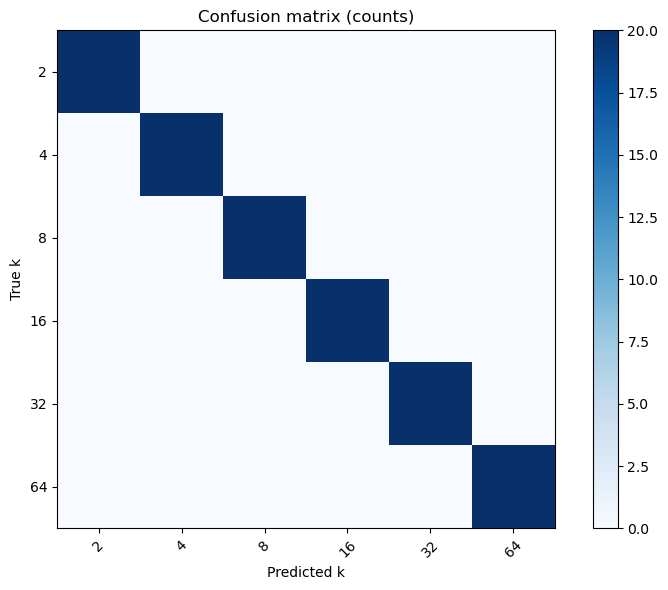

              precision    recall  f1-score   support

           2       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          32       1.00      1.00      1.00        20
          64       1.00      1.00      1.00        20

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

True k=2 -> Pred k=2 (prob=0.999)
True k=2 -> Pred k=2 (prob=1.000)
True k=2 -> Pred k=2 (prob=0.998)
True k=2 -> Pred k=2 (prob=0.973)
True k=2 -> Pred k=2 (prob=1.000)
True k=2 -> Pred k=2 (prob=0.999)
True k=2 -> Pred k=2 (prob=1.000)
True k=2 -> Pred k=2 (prob=0.997)
True k=2 -> Pred k=2 (prob=0.999)
True k=2 -> Pred k=2 (prob=1.000)


In [15]:
# Confusion matrix (counts) - minimal and direct
import numpy as np
import h5py
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

h5_path = 'fractal_dataset.h5'
model_path = 'checkpoints/best_model.h5'
samples_per_class = 20
batch_size = 16
random_seed = 42

# Load model
model = tf.keras.models.load_model(model_path)

# Collect samples
rng = np.random.RandomState(random_seed)
X_list = []
y_true_k = []
with h5py.File(h5_path, 'r') as f:
    groups = sorted([g for g in f.keys() if g.startswith('k_')], key=lambda s: int(s.split('_')[1]))
    for g in groups:
        imgs = f[f'{g}/images']
        n = imgs.shape[0]
        idxs = list(range(n)) if samples_per_class >= n else list(rng.choice(n, size=samples_per_class, replace=False))
        for i in idxs:
            im = np.array(imgs[i], dtype=np.float32)
            if im.ndim == 2:
                im = im[..., np.newaxis]
            X_list.append(im)
            y_true_k.append(int(g.split('_')[1]))

X = np.stack(X_list, axis=0)
print('Prepared X shape:', X.shape)

# Prepare class mapping consistent with training (numeric order)
with h5py.File(h5_path, 'r') as f:
    trained_groups = sorted([g for g in f.keys() if g.startswith('k_')], key=lambda s: int(s.split('_')[1]))
trained_k = np.array([int(g.split('_')[1]) for g in trained_groups], dtype=int)
k_to_idx = {int(k): i for i, k in enumerate(trained_k)}
y_true_idx = np.array([k_to_idx[k] for k in y_true_k], dtype=int)

# Predict
preds = []
for i in range(0, X.shape[0], batch_size):
    batch = X[i:i+batch_size]
    probs = model.predict(batch, batch_size=batch_size)
    preds.append(probs)
probs = np.vstack(preds)
y_pred_idx = probs.argmax(axis=1)
y_pred_k = trained_k[y_pred_idx]

# Confusion matrix (counts)
cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(len(trained_k))))

# Plot
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix (counts)')
plt.colorbar()
labels_k = [str(k) for k in trained_k]
plt.xticks(np.arange(len(labels_k)), labels_k, rotation=45)
plt.yticks(np.arange(len(labels_k)), labels_k)
plt.xlabel('Predicted k')
plt.ylabel('True k')
plt.tight_layout()
plt.show()

# Report (simple print)
print(classification_report(y_true_idx, y_pred_idx, target_names=labels_k))

# Small sample of predictions
for i in range(min(10, X.shape[0])):
    print(f'True k={y_true_k[i]} -> Pred k={int(y_pred_k[i])} (prob={probs[i].max():.3f})')

Trained k values: [ 2  4  8 16 32 64]
Prepared intermediate X shape: (100, 512, 512, 1)
Prepared intermediate X shape: (100, 512, 512, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step


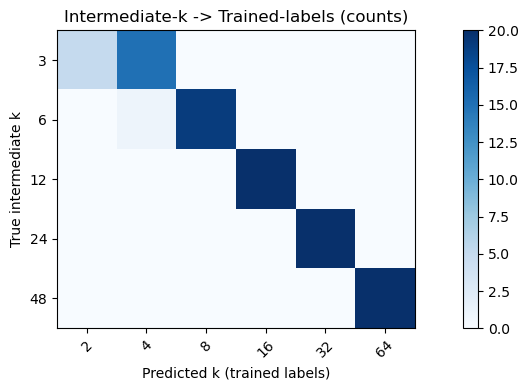

Inter k=3.0 (n=20) -> top preds: [(4, 15), (2, 5), (8, 0), (16, 0), (32, 0)]
Inter k=6.0 (n=20) -> top preds: [(8, 19), (4, 1), (2, 0), (16, 0), (32, 0)]
Inter k=12.0 (n=20) -> top preds: [(16, 20), (2, 0), (4, 0), (8, 0), (32, 0)]
Inter k=24.0 (n=20) -> top preds: [(32, 20), (2, 0), (4, 0), (8, 0), (16, 0)]
Inter k=48.0 (n=20) -> top preds: [(64, 20), (2, 0), (4, 0), (8, 0), (16, 0)]


In [16]:
# Confusion matrix for intermediate-k dataset (minimal, raw counts)
import numpy as np
import h5py
import tensorflow as tf
import matplotlib.pyplot as plt

inter_h5 = 'fractal_dataset_intermediate.h5'
model_path = 'checkpoints/best_model.h5'
samples_per_group = 20
batch_size = 16
random_seed = 42

# Load model
model = tf.keras.models.load_model(model_path)

# Trained k mapping (numeric order)
with h5py.File('fractal_dataset.h5', 'r') as f:
    trained_groups = sorted([g for g in f.keys() if g.startswith('k_')], key=lambda s: int(s.split('_')[1]))
trained_k = np.array([int(g.split('_')[1]) for g in trained_groups], dtype=int)
print('Trained k values:', trained_k)

# Read intermediate groups and sample images
rng = np.random.RandomState(random_seed)
X_list = []
y_true_k = []
inter_groups = []
with h5py.File(inter_h5, 'r') as f:
    groups = sorted([g for g in f.keys() if g.startswith('k_')], key=lambda s: float(s.split('_')[1]))
    inter_groups = groups
    for g in groups:
        imgs = f[f'{g}/images']
        n = imgs.shape[0]
        idxs = list(range(n)) if samples_per_group >= n else list(rng.choice(n, size=samples_per_group, replace=False))
        for i in idxs:
            im = np.array(imgs[i], dtype=np.float32)
            if im.ndim == 2:
                im = im[..., np.newaxis]
            X_list.append(im)
            y_true_k.append(float(g.split('_')[1]))

X = np.stack(X_list, axis=0)
print('Prepared intermediate X shape:', X.shape)

# Predict
preds = []
for i in range(0, X.shape[0], batch_size):
    batch = X[i:i+batch_size]
    probs = model.predict(batch, batch_size=batch_size)
    preds.append(probs)
probs = np.vstack(preds)
y_pred_idx = probs.argmax(axis=1)
y_pred_k = trained_k[y_pred_idx]

# Build counts matrix (rows = intermediate true k, cols = trained_k predictions)
inter_k_list = [float(g.split('_')[1]) for g in inter_groups]
inter_k_to_idx = {k: i for i, k in enumerate(inter_k_list)}
cm_counts = np.zeros((len(inter_k_list), len(trained_k)), dtype=int)
for tk, p_idx in zip(y_true_k, y_pred_idx):
    r = inter_k_to_idx[float(tk)]
    cm_counts[r, int(p_idx)] += 1

# Plot
plt.figure(figsize=(10, max(4, 0.6*len(inter_k_list))))
plt.imshow(cm_counts, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Intermediate-k -> Trained-labels (counts)')
plt.colorbar()
plt.xticks(np.arange(len(trained_k)), [str(k) for k in trained_k], rotation=45)
plt.yticks(np.arange(len(inter_k_list)), [str(int(k) if float(k).is_integer() else k) for k in inter_k_list])
plt.xlabel('Predicted k (trained labels)')
plt.ylabel('True intermediate k')
plt.tight_layout()
plt.show()

# Print summary per intermediate k
for i, tk in enumerate(inter_k_list):
    row = cm_counts[i]
    total = int(row.sum())
    top = sorted([(int(trained_k[j]), int(row[j])) for j in range(len(row))], key=lambda x: x[1], reverse=True)[:5]
    print(f'Inter k={tk} (n={total}) -> top preds: {top}')